In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [22]:
from sklearn.datasets import make_classification
X,y = make_classification (n_samples=1000,
                          n_features=20,
                          n_informative=2,
                          n_redundant=0,
                          n_classes=2,
                          class_sep=2,
                          random_state=1)

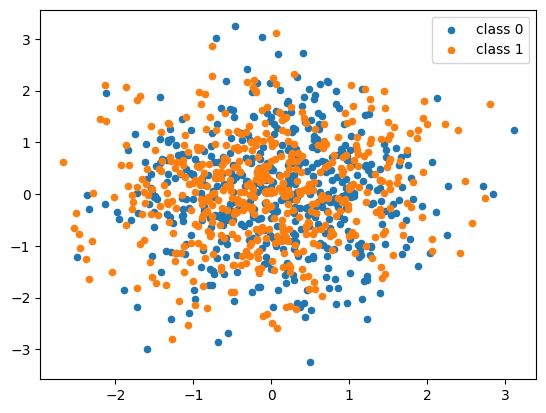

In [23]:
for cls in np.unique(y):
    plt.scatter(X[y==cls,0], X[y==cls,1], label=f'class {cls}', s=20)
plt.legend()
plt.show()

In [24]:
class SGD():
    def __init__(self, alpha=0.5, n_iters=1000):
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters

    def _add_bias(self, X): # addded this
        X = np.atleast_2d(X)
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def gradient_step(self, b, b_grad):
        return b - self._alpha * b_grad

    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        for i in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
        return b

    def fit(self, X, y):
        Xb = self._add_bias(X) # added this
        m = Xb.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(Xb, y, start_b, self._n_iters)


class LogReg(SGD):
    def sigmoid(self, X, b):
        return 1. / (1. + np.exp(-X.dot(b)))

    def grad_func(self, X, y, b):
        n = X.shape[0]
        return 1. / n * X.T.dot(self.sigmoid(X, b) - y)

    def predict_proba(self, X):
        Xb = self._add_bias(X) # bias here
        return self.sigmoid(Xb, self.b)

    def predict(self, X):
        return self.predict_proba(X) > 0.5

In [25]:
logreg = LogReg(alpha=0.5, n_iters=1000)
logreg.fit(X, y)
y_pred = logreg.predict(X)
print("accuracy:", accuracy_score(y, y_pred))

accuracy: 0.976
